<a href="https://colab.research.google.com/github/sanika203/breast-cancer-ml-analysis/blob/main/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (569, 30)

Model Results
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



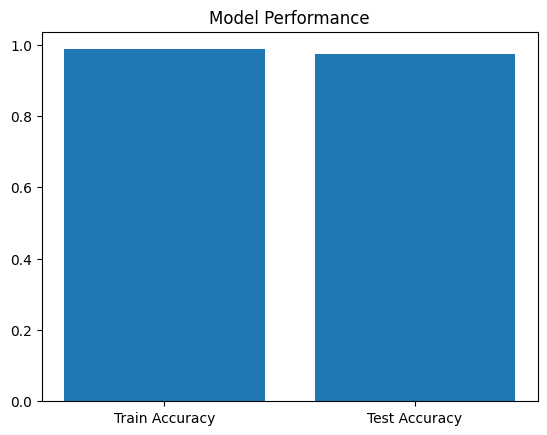

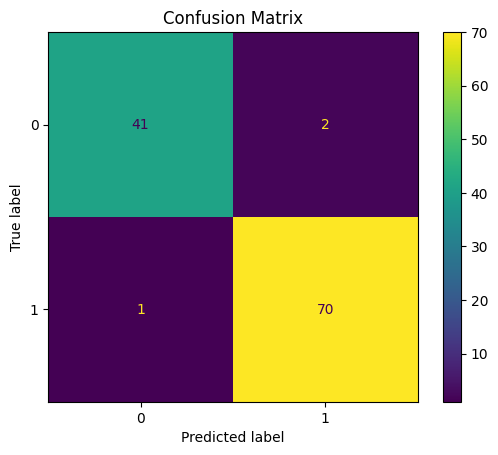


Top important features:
compactness error          0.682491
fractal dimension error    0.616230
mean compactness           0.540164
symmetry error             0.500425
mean symmetry              0.236119
texture error              0.188877
concavity error            0.175275
mean fractal dimension     0.075921
worst compactness          0.016110
mean smoothness           -0.071667
dtype: float64


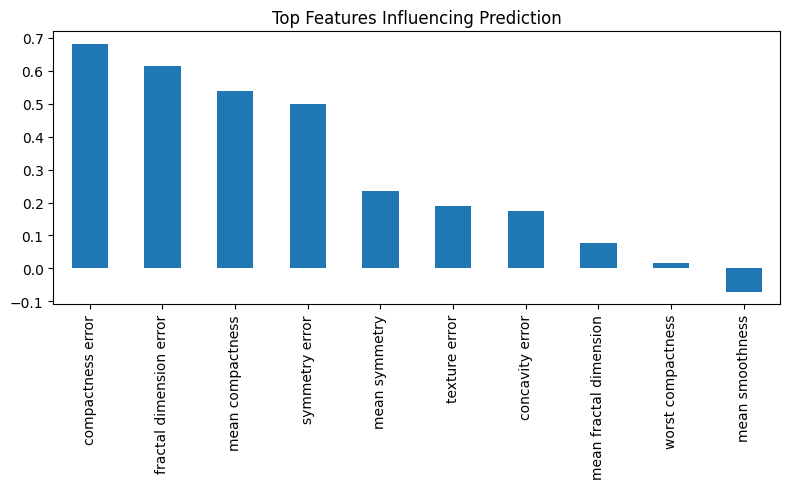

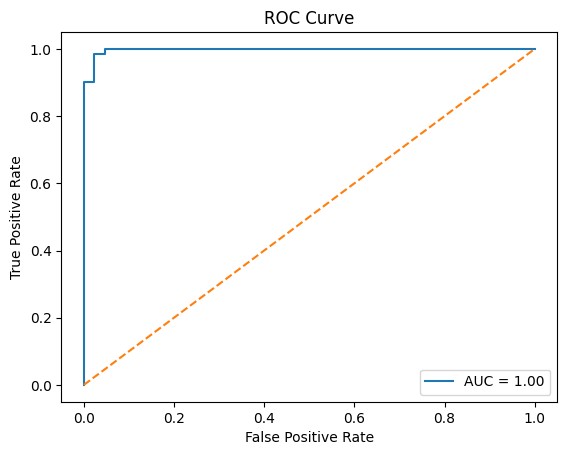

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# load dataset from sklearn
data = load_breast_cancer()

# convert to dataframe for easier handling
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)


# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# simple logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# predictions
y_pred = model.predict(X_test_scaled)

print("\nModel Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# Train vs Test accuracy plot
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

plt.figure()
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.title("Model Performance")
plt.show()


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


# plot feature importance (based on coefficients)
importance = pd.Series(model.coef_[0], index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

print("\nTop important features:")
print(top_features)

plt.figure(figsize=(8,5))
top_features.plot(kind="bar")
plt.title("Top Features Influencing Prediction")
plt.tight_layout()
plt.show()
# ROC Curve (medical diagnostic style evaluation)

# probability scores instead of class labels
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
